# <span style="color:#5dff12">🌱 Grow-Light Photon-Flux Calculator</span>

**Description:**  
This notebook computes both total and spectral photon-flux density (PPFD) for a 2D array of multi-spectral LEDs.
Designed for real-world horticultural planning with robust physics and interactive plots.

**Last updated:** 2025-04-30

---

## 📑 Table of Contents
1. [Physics Background](#physics)
2. [LED Layout Definition](#layout)
3. [Constants & Helper Functions](#helpers)
4. [LED Specs & Assembly](#assembly)
5. [Compute Total PPFD Grid](#ppfd)
6. [Interactive 3D PPFD Plot](#surface)
7. [Spectral PPFD Surface with Slider](#spectral3d)
8. [Region-Average PPFD & Spectral Plot](#region)
9. [References](#refs)


## <a href="#physics">1. Physics Background</a>

Understanding light for plants requires a blend of radiometry and photometry, plus photon-counting for biological action.

- **Radiant power** $P$ (W): actual electromagnetic power output.  
- **Radiant intensity** $I_e$ (W·sr⁻¹): power per unit solid angle.  
- **Irradiance** $E$ (W·m⁻²): power per unit area.  
- **Luminous flux** $\Phi$ (lm): power weighted by human photopic response.  
- **Luminous intensity** $I_v$ (cd): luminous flux per solid angle.  
- **Photon energy** $E_\gamma = h c/\lambda$.  
- **PPFD** $\phi$ (μmol·s⁻¹·m⁻²): photosynthetic photon flux density across 380–780 nm.

### Key equations

1. **Beam shape to on-axis luminous intensity**  
   $$I_{v0} = \Phi\;\frac{m+1}{2\pi}, \quad m = \frac{\ln0.5}{\ln\cos\theta_{1/2}}.$$
2. **Luminous to radiant intensity**  
   - Narrowband at $\lambda_0$:  
     $$I_{e0} = \frac{I_{v0}}{683\,V(\lambda_0)}.$$  
   - White LED with LER:  
     $$I_{e0} = \frac{I_{v0}}{\mathrm{LER}}.$$
3. **Radiant intensity to irradiance**  
   $$E(θ) = \frac{I_{e0}\cos^mθ}{r^2}, \quad r=\sqrt{Δx^2 + Δy^2 + z^2}.$$
4. **Irradiance to photon flux density**  
   $$\phi = E\;\frac{\lambda}{h c}\;\frac{10^6}{N_A}.$$

These ensure conversion from candela‐based datasheet specs to actual photon flux for plants.


## 2. LED Layout Definition <a href="#layout"></a>

Define your LED matrix (`layout`) and positions (`layout_coords`), both matching in shape.  
- `layout[i][j]`: integer type index for the LED at row i, column j.  
- `layout_coords[i][j]`: `(x_mm, y_mm)` coordinates in millimeters on the LED plane.


In [9]:
bounds = (134.62, 153.67)  # mm

spacing_x_5 = [21.59, 22.86, 21.59, 22.868, 22.86]  # mm
spacing_x_4 = [33.016, 22.855, 21.599, 22.86]  # mm
spacing_y = [15.295, 13.97, 13.97, 13.97, 13.97, 13.97, 14.009, 13.97, 13.936, 13.97]  # mm

for i in range(1, len(spacing_x_5)):
    spacing_x_5[i] += spacing_x_5[i - 1]
for i in range(1, len(spacing_x_4)):
    spacing_x_4[i] += spacing_x_4[i - 1]
for i in range(1, len(spacing_y)):
    spacing_y[i] += spacing_y[i - 1]

# Convenience
spacing_x = {
    5: spacing_x_5,
    4: spacing_x_4
}

module_layout = (
    (0, 0, 1, 0, 0),
    (0, 1, 0, 0),
    (0, 0, 2, 0, 1),
    (0, 0, 1, 0),
    (0, 0, 1, 0, 2),
    (0, 1, 0, 0),
    (0, 1, 0, 0, 0),
    (0, 1, 1, 0),
    (0, 0, 2, 0, 1),
    (0, 1, 0, 0)
)

intramodular_spacing = 7.68 + 0.2  # mm, value + tolerance (y axis)

# Reverse because the light is pointing down
module_layout = tuple(reversed(module_layout))

n_modules = 5

layout_coords = []
for m_n in range(n_modules):
    for i, row in enumerate(module_layout):
        row_coords = []
        for j, led in enumerate(row):
            row_coords.append((spacing_x[len(row)][j], spacing_y[i] + m_n * (spacing_y[-1] + intramodular_spacing)))
        layout_coords.append(row_coords)

layout = module_layout * n_modules

sim_bounds = ((-0.05, 0.05 + bounds[0] / 1000), (-0.2, 0.2 + bounds[1] * n_modules / 1000))

## 3. Constants & Helper Functions <a href="#helpers"></a>

Load libraries, define constants, photopic lookup, and Lambertian exponent helper.


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# Physical constants
h = 6.62607015e-34  # Planck constant (J·s)
c = 2.99792458e8    # Speed of light (m/s)
N_A = 6.02214076e23 # Avogadro's number (mol⁻¹)
LM555 = 683         # lm/W at 555 nm

# Load photopic luminosity from CSV
_phot = np.loadtxt('external/CIE_sle_photopic.csv', delimiter=',')
_phot_wl = _phot[:,0].astype(int)
_phot_v  = _phot[:,1]
_max_wl = _phot_wl.max()
_V_lut = np.zeros(_max_wl + 1)
for wl, v in zip(_phot_wl, _phot_v):
    _V_lut[wl] = v

def v_lambda(lam_nm):
    """Snap to nearest int nm, return V(λ), zero outside data."""
    lam = np.round(lam_nm).astype(int)
    out = np.zeros_like(lam, dtype=float)
    mask = (lam>=0)&(lam<=_max_wl)
    out[mask] = _V_lut[lam[mask]]
    return out if out.shape else float(out)

def lambert_m(theta_half_deg):
    """Lambertian exponent m from half-power angle in degrees."""
    return np.log(0.5)/np.log(np.cos(np.deg2rad(theta_half_deg)))


## 4. LED Specifications & Assembly <a href="#assembly"></a>

Define datasheet parameters at your operating current (e.g., 350 mA):  
- `Phi` (lm): total forward luminous flux  
- `theta_half` (°): half-power angle  
- `lambda_peak` (nm): peak wavelength for narrowband  
- `spectral_width_nm` (nm): FWHM for Gaussian SPD  
- `LER` (lm/W): luminous efficacy for white LEDs  

Then assemble the flat `leds` list from your layout.


In [11]:
# Example datasheet specs @350 mA
led_type_specs = {
    0: dict(name='Red',   Phi=50, theta_half=70, lambda_peak=622, spectral_width_nm=28),
    1: dict(name='Blue',  Phi=20, theta_half=60, lambda_peak=465, spectral_width_nm=30),
    2: dict(name='White', Phi=65, theta_half=60, LER=300, lambda_peak=585, spectral_width_nm=15)
}

# Build leds list in meters
leds = []
for i, row in enumerate(layout):
    for j, t in enumerate(row):
        spec = led_type_specs[int(t)].copy()
        x_mm, y_mm = layout_coords[i][j]
        spec['x'], spec['y'] = x_mm/1000, y_mm/1000
        spec['distribution'] = 'Lambertian'
        leds.append(spec)

print(f"✔ Loaded {len(leds)} LEDs.")


✔ Loaded 225 LEDs.


## 5. Compute Total PPFD Grid <a href="#ppfd"></a>

Calculate PPFD (μmol·s⁻¹·m⁻²) on a uniform grid at distance `z`.


In [12]:
# Grid parameters
z = 0.3  # separation in meters
(x1, x2), (y1, y2) = sim_bounds
x_coords  = np.linspace(x1, x2, 2000)
y_coords  = np.linspace(y1, y2, 2000)
xg, yg    = np.meshgrid(x_coords, y_coords)
phi_total = np.zeros_like(xg)

# Summation over LEDs
for led in leds:
    dx, dy = xg - led['x'], yg - led['y']
    r          = np.sqrt(dx*dx + dy*dy + z*z)
    cos_t      = np.clip(z/r, 0, 1)
    m          = lambert_m(led['theta_half'])
    Iv0        = led['Phi']*(m+1)/(2*np.pi)
    Ie0        = Iv0/led.get('LER', LM555 * v_lambda(led['lambda_peak']))
    E          = Ie0 * cos_t**m / r**2
    phi_total += E * (led['lambda_peak']*1e-9)/(h*c) * 1e6/N_A


## 6. Interactive 3D PPFD Plot <a href="#surface"></a>

Use `%matplotlib widget` to interactively rotate and inspect.


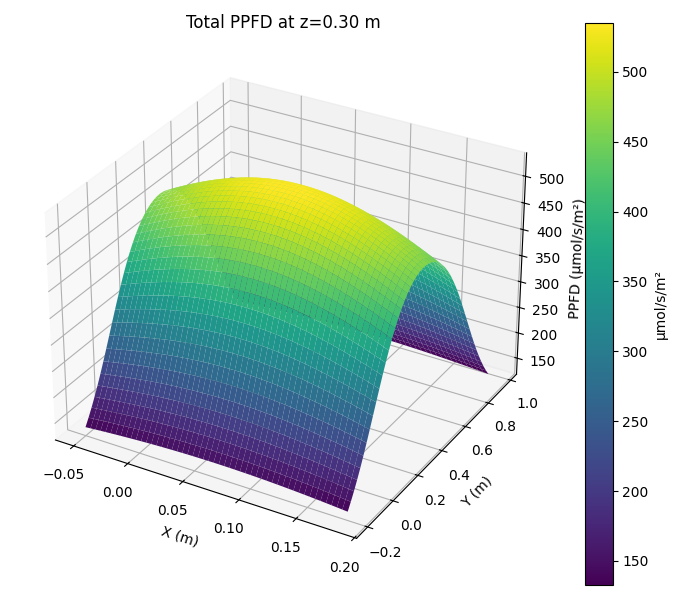

In [13]:
%matplotlib widget
fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(xg, yg, phi_total, cmap='viridis', linewidth=0)
ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)'); ax.set_zlabel('PPFD (μmol/s/m²)')
ax.set_title(f'Total PPFD at z={z:.2f} m')
fig.colorbar(surf, ax=ax, label='μmol/s/m²')
plt.tight_layout()


## 7. Spectral PPFD Surface with Slider <a href="#spectral3d"></a>

Plot φ(λ) surface (X vs λ vs φ) for variable Y.


In [24]:
import torch
import ppfd_compute

# Define axes
x1, x2 = sim_bounds[0]
x_coords = np.linspace(x1, x2, 2000)
wavelengths = np.linspace(380, 780, 2000)

# --- Precompute per‐LED normalized SPDs and photon conversion factor ---

# Wavelength axis in meters
lam_m = wavelengths * 1e-9
photon_conv = lam_m/(h*c) * 1e6/N_A  # shape (nλ,)

# 1.2 For each LED, compute m, I_e0 and normalized SPD×photon_conv
for led in leds:
    # Lambertian exponent
    led['m'] = lambert_m(led['theta_half'])
    # On-axis Iv and Ie
    Iv0 = led['Phi']*(led['m']+1)/(2*np.pi)
    led['Ie0'] = Iv0 / led.get('LER', LM555 * v_lambda(led['lambda_peak']))
    # Pre-normalize SPD once
    sig = led['spectral_width_nm'] / 2.355
    spd = np.exp(-0.5 * ((wavelengths-led['lambda_peak']) / sig) ** 2)
    spd /= np.trapezoid(spd, wavelengths)
    # Multiply by photon_conv up front
    led['spd_q'] = spd * photon_conv    # shape (nλ,)

# Stack per-LED arrays
xs   = np.array([led['x']     for led in leds])          # (L,)
ys   = np.array([led['y']     for led in leds])          # (L,)
ms   = np.array([led['m']     for led in leds])          # (L,)
Ie0s = np.array([led['Ie0']   for led in leds])          # (L,)
SPDs = np.stack([led['spd_q'] for led in leds], axis=1)  # (nλ, L)

def compute_phi_matrices(y_values):
    """Compute φ(λ) matrices for a given range of y coordinates."""

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Convert to torch tensors (float64 for precision; change to float32 if desired)
    xs_t           = torch.tensor(xs,           dtype=torch.float64, device=device)  # shape (L,)
    ys_t           = torch.tensor(ys,           dtype=torch.float64, device=device)  # shape (L,)
    y_values_t     = torch.tensor(y_values,     dtype=torch.float64, device=device)  # shape (L,)
    Ie0s_t         = torch.tensor(Ie0s,         dtype=torch.float64, device=device)  # shape (L,)
    ms_t           = torch.tensor(ms,           dtype=torch.float64, device=device)  # shape (L,)
    lam_m_t        = torch.tensor(lam_m,        dtype=torch.float64, device=device)  # shape (n_lambda,)
    photon_conv_t  = torch.tensor(photon_conv,  dtype=torch.float64, device=device)  # shape (n_lambda,)
    SPDs_t         = torch.tensor(SPDs,         dtype=torch.float64, device=device)  # shape (n_lambda, L)
    x_coords_t     = torch.tensor(x_coords,     dtype=torch.float64, device=device)  # shape (nx,)
    z_t            = torch.tensor(z,            dtype=torch.float64, device=device)  # scalar
    streams = [torch.cuda.Stream(device=device) for _ in range(len(y_values_t))]
    outputs = [None] * len(y_values_t)

    for _i, (y_s, stream) in enumerate(zip(y_values_t, streams)):
        with torch.cuda.stream(stream):
            outputs[_i] = ppfd_compute.compute_ppfd(
                xs_t, ys_t, y_s.unsqueeze(0), Ie0s_t, ms_t,
                lam_m_t, photon_conv_t, SPDs_t, x_coords_t, z_t
            ).cpu().detach().numpy()

    # Synchronize all streams before using results
    for s in streams:
        s.synchronize()

    return outputs

# --- Old compute_phi_matrix (slow) ---
#
# def compute_phi_matrix(y_s):
#     Z = np.zeros((len(wavelengths), len(x_coords)))
#     for _j, x_s in enumerate(x_coords):
#         φ = np.zeros_like(wavelengths)
#         for _led in leds:
#             _dx, _dy = x_s - _led['x'], y_s - _led['y']
#             _r = np.sqrt(_dx * _dx + _dy * _dy + z * z)
#             _cos_t = np.clip(z / _r, 0, 1)
#             _m = lambert_m(_led['theta_half'])
#             _Iv0 = _led['Phi'] * (_m + 1) / (2 * np.pi)
#             _Ie0 = _Iv0 / _led.get('LER', LM555 * V_lambda(_led['lambda_peak']))
#             Ieθ = _Ie0 * _cos_t ** _m
#             σ = _led['spectral_width_nm'] / 2.355
#             spd = np.exp(-0.5 * ((wavelengths - _led['lambda_peak']) / σ) ** 2)
#             spd /= np.trapezoid(spd, wavelengths)
#             Eλ = Ieθ * spd / _r ** 2
#             φ += Eλ * (wavelengths*1e-9)/(h*c) * 1e6/N_A
#         Z[:, _j] = φ
#     return Z

# Interactive slider
y1, y2 = sim_bounds[1]
y_slider = widgets.FloatSlider(value=0, min=y1, max=y2, step=0.001,
                               orientation='horizontal', description='y (m)')
fig_out = widgets.Output()
precompute = compute_phi_matrices(np.linspace(y1, y2, int(1000 * (y2 - y1))) + 1)

def draw(y):
    with fig_out:
        fig_out.clear_output(wait=True)
        fig = plt.figure(figsize=(7,6))
        ax = fig.add_subplot(111, projection='3d')
        X, Y = np.meshgrid(x_coords, wavelengths)
        matrix = precompute[int(y*1000)]
        surf = ax.plot_surface(X, Y, matrix, cmap='plasma', linewidth=0)
        ax.set_xlabel('X (m)'); ax.set_ylabel('Wavelength (nm)'); ax.set_zlabel('φ (μmol/s/m²/nm)')
        ax.set_title(f'Spectral PPFD at y={y:.3f} m')
        fig.colorbar(surf, ax=ax, label='μmol/s/m²/nm')
        plt.tight_layout()

draw(y_slider.value)
y_slider.observe(lambda ch: draw(ch.new), names='value')
display(widgets.VBox([fig_out, y_slider]))


KeyboardInterrupt: 

## 8. Region-Average PPFD & Spectral Plot <a href="#region"></a>

Compute average PPFD in μmol·s⁻¹·mm⁻² and spectral profile over a rectangular region.


In [23]:
# Region bounds (m)
(x1, x2), (y1, y2) = sim_bounds

mask_x = (x_coords>=x1)&(x_coords<=x2)
mask_y = (y_coords>=y1)&(y_coords<=y2)

# Average total PPFD
phi_avg = phi_total[np.ix_(mask_y, mask_x)].mean()
print(f"✔ Region-average PPFD = {phi_avg:.3f} μmol·s⁻¹·m⁻²")

# Average spectral PPFD
phi_spec = np.zeros_like(wavelengths)
y_v = np.where(mask_y)[0]
x_v = np.where(mask_x)[0]

matrices = compute_phi_matrices(y_coords[y_v])
for i, matrix in enumerate(matrices):
    for j in x_v:
        phi_spec += matrix[:, j]

phi_spec_avg = phi_spec / x_v / y_v

plt.figure(figsize=(8,4))
plt.plot(wavelengths, phi_spec_avg, lw=2)
plt.xlabel('Wavelength (nm)'); plt.ylabel('φ (μmol/s/m²/nm)')
plt.title('Spectral average over region')
plt.grid(True); plt.tight_layout()


✔ Region-average PPFD = 360.330 μmol·s⁻¹·m⁻²


ValueError: operands could not be broadcast together with shapes (401,) (2000,) 

## 9. References <a href="#refs"></a>

- TUOZHAN S2-2835 R/B/W datasheets (LCSC)  
- CIE 1931 photopic luminous-efficiency function  
- ANSI/IES TM-30-20 spectral calculation guidelines  
